In [ ]:
from google.colab import drive
drive.mount("/content/drive")

PROJECT_DIR = "/content/drive/MyDrive/Project_AUTO_ReID"


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
%pip install -q -U transformers
%pip install -q -U ultralytics

In [ ]:
# Install/Reinstall torch and transformers for compatibility
# IMPORTANT: After running this cell, please restart the runtime (Runtime > Restart runtime...)
!pip install -q torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu

# Standard library
from dataclasses import dataclass
from pathlib import Path
from typing import Protocol, TypeAlias

# Numerical processing and model inference
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F

# Image loading and result visualisation
from PIL import Image
import matplotlib.pyplot as plt
from IPython.display import display

# DINOv2 model and preprocessing
from transformers import AutoImageProcessor, AutoModel

In [ ]:
PROJECT_DIR = Path(
    "/content/drive/MyDrive/Project_AUTO_ReID"
)

REFERENCE_DIR = PROJECT_DIR / "references"
QUERY_DIR = PROJECT_DIR / "queries"
EMBEDDINGS_DIR = PROJECT_DIR / "embeddings"
EMBEDDINGS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR = PROJECT_DIR / "results"


In [ ]:
TEMP_CROPPED_DIR = PROJECT_DIR / "temp_cropped_images"
TEMP_CROPPED_DIR.mkdir(parents=True, exist_ok=True)
print("Temporary cropped images folder:", TEMP_CROPPED_DIR)

Temporary cropped images folder: /content/drive/MyDrive/Project_AUTO_ReID/temp_cropped_images


In [ ]:
print("Project:", PROJECT_DIR)
print("References found:", REFERENCE_DIR.exists())
print("Queries found:", QUERY_DIR.exists())
print("Embeddings folder:", EMBEDDINGS_DIR)
print("Results folder:", RESULTS_DIR)

Project: /content/drive/MyDrive/Project_AUTO_ReID
References found: True
Queries found: True
Embeddings folder: /content/drive/MyDrive/Project_AUTO_ReID/embeddings
Results folder: /content/drive/MyDrive/Project_AUTO_ReID/results


In [ ]:
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".webp"}

def get_image_paths(folder: Path) -> list[Path]:
    return sorted(
        path
        for path in folder.rglob("*")
        if path.is_file()
        and path.suffix.lower() in IMAGE_EXTENSIONS
    )

for folder in sorted(REFERENCE_DIR.iterdir()):
    if folder.is_dir():
        print(
            f"Reference — {folder.name}: "
            f"{len(get_image_paths(folder))} images"
        )

for folder in sorted(QUERY_DIR.iterdir()):
    if folder.is_dir():
        print(
            f"Query — {folder.name}: "
            f"{len(get_image_paths(folder))} images"
        )

Reference — .ipynb_checkpoints: 0 images
Reference — black_mug_01: 4 images
Reference — book_01: 4 images
Reference — white_headphone_01: 4 images
Reference — white_mug_01: 4 images
Query — .ipynb_checkpoints: 0 images
Query — black_mug_01: 2 images
Query — book_01: 2 images
Query — unknown: 2 images
Query — white_headphone_01: 2 images
Query — white_mug_01: 2 images


In [ ]:
def _crop_image_with_bbox(
    original_image: Image.Image,
    bbox_xyxy: tuple[int, int, int, int],
    original_img_path: Path
) -> Path:
    x1, y1, x2, y2 = bbox_xyxy

    # Calculate width and height of the original bbox
    bbox_width = x2 - x1
    bbox_height = y2 - y1

    # Calculate 5% padding based on bbox dimensions
    padding_x = int(0.05 * bbox_width)
    padding_y = int(0.05 * bbox_height)

    # Apply padding, ensuring it stays within image bounds
    x1_padded = max(0, x1 - padding_x)
    y1_padded = max(0, y1 - padding_y)
    x2_padded = min(original_image.width, x2 + padding_x)
    y2_padded = min(original_image.height, y2 + padding_y)

    cropped_image = original_image.crop((x1_padded, y1_padded, x2_padded, y2_padded))

    # Save cropped image to a temporary path
    temp_filename = f"{original_img_path.stem}_yolo_padded_cropped{original_img_path.suffix}"
    temp_cropped_path = TEMP_CROPPED_DIR / temp_filename
    temp_cropped_path.parent.mkdir(parents=True, exist_ok=True)  # Ensure dir exists
    cropped_image.save(temp_cropped_path)
    return temp_cropped_path

def detect_object(img_path_list: list[Path]) -> list[tuple[Path, tuple[int, int, int, int] | None]]:
    processed_results = []
    for img_path in img_path_list:
        original_image = Image.open(img_path).convert("RGB")
        # Perform object detection
        # Using verbose=False to suppress print statements from YOLO
        results = yolo_model.predict(str(img_path), conf=0.25, iou=0.45, verbose=False)

        if results and results[0].boxes:  # Check if any objects were detected
            # Get the bounding boxes and areas
            boxes = results[0].boxes.xywh.cpu().numpy()  # xywh format
            areas = boxes[:, 2] * boxes[:, 3]  # width * height

            # Find the index of the largest bounding box
            largest_box_idx = np.argmax(areas)
            largest_box = boxes[largest_box_idx]

            # Convert xywh to xyxy for cropping (x_min, y_min, x_max, y_max)
            x_center, y_center, width, height = largest_box
            x1 = max(0, int(x_center - width / 2))
            y1 = max(0, int(y_center - height / 2))
            x2 = min(original_image.width, int(x_center + width / 2))
            y2 = min(original_image.height, int(y_center + height / 2))

            # Store the bbox relative to the original image
            bbox_original = (x1, y1, x2, y2)

            # Call the new cropping function to get the cropped image path
            cropped_path = _crop_image_with_bbox(original_image, bbox_original, img_path)
            processed_results.append((cropped_path, bbox_original))
        else:
            # If no objects detected, return original image path and no bbox
            processed_results.append((img_path, None))
    return processed_results

In [ ]:
MODEL_NAME = "facebook/dinov2-base"

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

processor = AutoImageProcessor.from_pretrained(MODEL_NAME)

model = AutoModel.from_pretrained(MODEL_NAME)
model = model.to(DEVICE)
model.eval()

print("Model:", MODEL_NAME)
print("Device:", DEVICE)

preprocessor_config.json:   0%|          | 0.00/436 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/548 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  346MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

Model: facebook/dinov2-base
Device: cuda


In [ ]:
from transformers import Sam2Processor, Sam2Model


SAM_MODEL_NAME = "facebook/sam2-hiera-tiny"

sam_processor = Sam2Processor.from_pretrained(
    SAM_MODEL_NAME
)

sam_model = Sam2Model.from_pretrained(
    SAM_MODEL_NAME
).to(DEVICE)

sam_model.eval()

print("Segmentation model:", SAM_MODEL_NAME)
print("Device:", DEVICE)

processor_config.json:   0%|          | 0.00/95.0 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/683 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/5.70k [00:00<?, ?B/s]

[transformers] You are using a model of type `sam2_video` to instantiate a model of type `sam2`. This may be expected if you are loading a checkpoint that shares a subset of the architecture (e.g., loading a `sam2_video` checkpoint into `Sam2Model`), but is otherwise not supported and can yield errors. Please verify that the checkpoint is compatible with the model you are instantiating.


model.safetensors: reconstructing file:   0%|          |  0.00B /  156MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/309 [00:00<?, ?it/s]

Segmentation model: facebook/sam2-hiera-tiny
Device: cuda


In [ ]:
from ultralytics import YOLO

YOLO_MODEL_NAME = "yolov8n.pt"  # Using yolov8n as a common lightweight model

yolo_model = YOLO(YOLO_MODEL_NAME)
yolo_model.to(DEVICE)  # Move YOLO model to the same device as DINOv2 and SAM
yolo_model.eval()  # Set to evaluation mode

print("Object detection model:", YOLO_MODEL_NAME)
print("Device:", DEVICE)

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.
Object detection model: yolov8n.pt
Device: cuda


In [ ]:
def apply_sam_mask(
    image_to_mask_path: Path, # Changed from original_image_path
    object_point: tuple[int, int] | None = None,
    bbox: tuple[int, int, int, int] | None = None, # New argument for bbox prompt
    background_colour: tuple[int, int, int] = (128, 128, 128),
) -> Image.Image:
    """
    Pass an image through SAM 2, select the best non-empty mask,
    and replace every pixel where the mask equals 0 with grey.

    Mask value 1/True  -> retain the original image pixel
    Mask value 0/False -> replace with background_colour
    """

    # 1. Load the image. This is now expected to be the (potentially cropped) image.
    image = Image.open(image_to_mask_path).convert("RGB")
    width, height = image.size

    # SAM 2 requires a prompt identifying the target object.
    # Prioritize bounding box prompt over object point.
    input_points = None
    input_labels = None
    input_boxes = None

    if bbox is not None:
        # SAM expects boxes in format [x_min, y_min, x_max, y_max]
        # The bbox is now expected to be relative to `image_to_mask_path`
        input_boxes = [[[float(bbox[0]), float(bbox[1]), float(bbox[2]), float(bbox[3])]]]
    elif object_point is not None:
        point_x, point_y = object_point
        input_points = [[[[
                float(point_x),
                float(point_y),
            ]
        ]]]
        # Label 1 means that the point is on the target object.
        input_labels = [[[1]]]
    else:
        # Default to image center if no bbox or object_point provided
        object_point = (
            width // 2,
            height // 2,
        )
        point_x, point_y = object_point
        input_points = [[[[
                float(point_x),
                float(point_y),
            ]
        ]]]
        input_labels = [[[1]]]

    # 2. Process the image and prompt, then move tensors to GPU.
    inputs = sam_processor(
        images=image,
        input_points=input_points,
        input_labels=input_labels,
        input_boxes=input_boxes, # Pass input_boxes
        return_tensors="pt",
    ).to(DEVICE)

    # 3. Pass the image through SAM 2.
    with torch.inference_mode():
        outputs = sam_model(
            **inputs,
            multimask_output=True,
        )

    # 4. Resize SAM's masks to the original image resolution.
    processed_masks = sam_processor.post_process_masks(
        outputs.pred_masks.cpu(),
        inputs["original_sizes"].cpu(),
        mask_threshold=0.0,
        binarize=True,
    )[0]

    # processed_masks shape:
    # [number_of_objects, number_of_candidate_masks, height, width]

    mask_scores = (
        outputs.iou_scores[0, 0]
        .detach()
        .cpu()
    )

    # 5. Exclude any completely empty candidate masks.
    mask_areas = torch.tensor([
        processed_masks[0, index].sum().item()
        for index in range(processed_masks.shape[1])
    ])

    valid_masks = mask_areas > 0

    if not valid_masks.any():
        raise RuntimeError(
            "SAM 2 returned only empty masks. "
            "Choose an object_point located inside the object."
        )

    valid_scores = mask_scores.clone()
    valid_scores[~valid_masks] = float("-inf")

    best_mask_index = int(
        torch.argmax(valid_scores).item()
    )

    # 6. Extract the selected binary mask.
    foreground_mask = (
        processed_masks[0, best_mask_index]
        .numpy()
        .astype(bool)
    )

    # 7. Copy the original image.
    masked_image_np = np.array(
        image,
        dtype=np.uint8,
        copy=True,
    )

    # Wherever the mask is 0/False, replace the pixel with grey.
    masked_image_np[foreground_mask] = np.asarray(
        background_colour,
        dtype=np.uint8,
    )

    retained_percentage = (
        foreground_mask.sum()
        / foreground_mask.size
        * 100
    )

    print("Selected mask:", best_mask_index)
    print(
        "Mask score:",
        f"{mask_scores[best_mask_index].item():.4f}",
    )
    print(
        "Image retained:",
        f"{retained_percentage:.2f}%",
    )

    return Image.fromarray(masked_image_np)

### Visualizing Preprocessed Reference Images

This function demonstrates the YOLO cropping and SAM masking process on the first image of each identity within your `reference_gallery`. This helps to visualize how the images are preprocessed before their embeddings are created.

In [ ]:
import torch

@torch.inference_mode()
def create_embedding(image: Image.Image) -> torch.Tensor:
    # image: Image.Image is now directly passed, removing the need to open from path

    inputs = processor(
        images=image,
        return_tensors="pt",
    )

    inputs = {
        name: tensor.to(DEVICE)
        for name, tensor in inputs.items()
    }

    outputs = model(**inputs)

    # CLS token represents the overall image.
    embedding = outputs.last_hidden_state[:, 0, :]

    # Normalize so dot product can be used as cosine similarity.
    embedding = F.normalize(
        embedding,
        p=2,
        dim=1,
    )

    return embedding.squeeze(0).cpu()

In [ ]:
def build_reference_gallery():
    # Build locally so an interruption cannot erase a valid gallery.
    new_gallery = {}

    for identity_folder in sorted(REFERENCE_DIR.iterdir()):
        if not identity_folder.is_dir():
            continue

        original_paths = get_image_paths(identity_folder)
        if not original_paths:
            continue

        successful_paths = []
        embeddings_list = []

        for original_path in original_paths:
            processed_results = detect_object([original_path])
            if not processed_results:
                print(f"Skipped: no detection for {original_path}")
                continue

            cropped_path, _ = processed_results[0]
            cropped_image = Image.open(cropped_path).convert("RGB")
            cropped_width, cropped_height = cropped_image.size
            sam_bbox = (0, 0, cropped_width, cropped_height)

            masked_image = apply_sam_mask(
                image_to_mask_path=cropped_path,
                bbox=sam_bbox,
            )

            embeddings_list.append(create_embedding(masked_image))
            successful_paths.append(str(original_path))

        if not embeddings_list:
            print(f"Skipped identity: {identity_folder.name}")
            continue

        embeddings = torch.stack(embeddings_list)
        new_gallery[identity_folder.name] = {
            "paths": successful_paths,
            "embeddings": embeddings,
        }
        print(identity_folder.name, embeddings.shape)

    if not new_gallery:
        raise RuntimeError(
            "No reference embeddings were created. "
            "Check REFERENCE_DIR and object detections."
        )

    return new_gallery


# Assignment occurs only after the complete build succeeds.
reference_gallery = build_reference_gallery()
print("Gallery identities:", list(reference_gallery.keys()))

Selected mask: 2
Mask score: 0.9830
Image retained: 66.98%
Selected mask: 2
Mask score: 0.9622
Image retained: 20.90%
Selected mask: 2
Mask score: 0.9698
Image retained: 38.66%
Selected mask: 2
Mask score: 0.4106
Image retained: 35.58%
black_mug_01 torch.Size([4, 768])
Selected mask: 2
Mask score: 0.9627
Image retained: 24.14%
Selected mask: 2
Mask score: 0.7373
Image retained: 49.67%
Selected mask: 2
Mask score: 0.5508
Image retained: 14.35%
Selected mask: 2
Mask score: 0.9781
Image retained: 50.87%
book_01 torch.Size([4, 768])
Selected mask: 2
Mask score: 0.9330
Image retained: 50.44%
Selected mask: 2
Mask score: 0.9727
Image retained: 58.77%
Selected mask: 2
Mask score: 0.6736
Image retained: 37.42%
Selected mask: 2
Mask score: 0.6137
Image retained: 80.95%
white_headphone_01 torch.Size([4, 768])
Selected mask: 2
Mask score: 0.9903
Image retained: 76.41%
Selected mask: 2
Mask score: 0.9770
Image retained: 33.03%
Selected mask: 2
Mask score: 0.9862
Image retained: 43.63%
Selected mas

In [ ]:
GALLERY_PATH = EMBEDDINGS_DIR / "reference_gallery.pt"

torch.save(
    {
        "model_name": MODEL_NAME,
        "gallery": reference_gallery,
    },
    GALLERY_PATH,
)

print("Saved:", GALLERY_PATH)

Saved: /content/drive/MyDrive/Project_AUTO_ReID/embeddings/reference_gallery.pt


In [ ]:
# def show_processed_reference_images():
#     for identity_name, evidence in reference_gallery.items():
#         print(f"\n--- Processing {identity_name} ---")
#         # Get the original path of the first image for this identity
#         original_path = Path(evidence["paths"][0])

#         # 1. Detect object and get cropped image path
#         # detect_object expects a list, even for a single image
#         processed_results = detect_object([original_path])
#         cropped_path, _ = processed_results[0]

#         # 2. Load the cropped image to determine its dimensions
#         cropped_image = Image.open(cropped_path).convert("RGB")
#         cropped_width, cropped_height = cropped_image.size

#         # 3. Define a bbox for SAM that covers the entire cropped image
#         sam_bbox_for_cropped_img = (0, 0, cropped_width, cropped_height)

#         # 4. Apply SAM mask to the cropped image
#         masked_image = apply_sam_mask(
#             image_to_mask_path=cropped_path,
#             bbox=sam_bbox_for_cropped_img
#         )

#         print(f"Original Image ({identity_name}): {original_path.name}")
#         display(Image.open(original_path).convert("RGB"))

#         print(f"Cropped Image ({identity_name}):")
#         display(cropped_image)

#         print(f"Masked Image ({identity_name}):")
#         display(masked_image)

# # Call the function to display the processed images
# show_processed_reference_images()

TODO: implement YOLO detection and then passoff to SAM before segmentation

In [ ]:
def compare_query(query_embedding: torch.Tensor):
    gallery = globals().get("reference_gallery")

    if not gallery:
        raise RuntimeError(
            "reference_gallery is empty or undefined. "
            "Run the complete gallery-building cell first."
        )

    query_embedding = query_embedding.squeeze().cpu()
    comparison_rows = []
    identity_rows = []

    for candidate_identity, evidence in gallery.items():
        reference_embeddings = evidence["embeddings"].cpu()
        reference_paths = evidence["paths"]

        if reference_embeddings.ndim != 2:
            raise ValueError(
                f"{candidate_identity} embeddings must have shape "
                f"[number_of_images, embedding_size], but received "
                f"{tuple(reference_embeddings.shape)}."
            )

        if reference_embeddings.shape[1] != query_embedding.shape[0]:
            raise ValueError(
                f"Embedding dimension mismatch for {candidate_identity}: "
                f"gallery={reference_embeddings.shape[1]}, "
                f"query={query_embedding.shape[0]}. "
                f"Regenerate the gallery using {MODEL_NAME}."
            )

        if len(reference_paths) != len(reference_embeddings):
            raise ValueError(
                f"Path/embedding count mismatch for {candidate_identity}: "
                f"{len(reference_paths)} paths and "
                f"{len(reference_embeddings)} embeddings."
            )

        # Normalized embeddings: dot product equals cosine similarity.
        similarities = reference_embeddings @ query_embedding

        # Diagnostic only: summarize this identity using its top-k matches.
        k = 3
        effective_k = min(k, len(similarities))
        top_k_similarities = torch.topk(
            similarities,
            k=effective_k,
        ).values
        top_k_mean = top_k_similarities.mean()

        # Keep the strongest individual reference as display evidence.
        best_index = int(similarities.argmax().item())
        best_reference_path = Path(reference_paths[best_index])
        identity_rows.append({
            "candidate_identity": candidate_identity,
            "reference_image": best_reference_path.name,
            "reference_path": str(best_reference_path),
            "best_similarity": float(similarities[best_index].item()),
            "top_k_mean": float(top_k_mean.item()),
        })

        print(
            candidate_identity,
            "all similarities:", similarities.tolist(),
            "top-k mean:", top_k_mean.item(),
        )

        for index, similarity in enumerate(similarities):
            reference_path = Path(reference_paths[index])
            comparison_rows.append({
                "query_identity": "UNKNOWN",
                "query_image": "UNKNOWN",
                "candidate_identity": candidate_identity,
                "reference_image": reference_path.name,
                "reference_path": str(reference_path),
                "best_similarity": float(similarity.item()),
            })

    if not comparison_rows:
        raise RuntimeError(
            "The gallery exists, but no comparisons were generated."
        )

    all_comparisons = (
        pd.DataFrame(comparison_rows)
        .sort_values("best_similarity", ascending=False)
        .reset_index(drop=True)
    )

    identity_matches = (
        pd.DataFrame(identity_rows)
        .sort_values("top_k_mean", ascending=False)
        .reset_index(drop=True)
    )

    return all_comparisons, identity_matches

The `reference_gallery` needs to be re-generated using the current DINOv2-base model to match the embedding dimensions of the query images. This will resolve the `RuntimeError: size mismatch`.

Now that the `reference_gallery` has been updated with the correct embedding dimensions, we can proceed with comparing query images and generating the summary.

In [ ]:
MATCH_VISUALS_DIR = RESULTS_DIR / "match_visuals"
MATCH_VISUALS_DIR.mkdir(parents=True, exist_ok=True)

def show_query_match(query_path: Path):
    # 1. Preprocess the query image: Crop and Mask
    # detect_object expects a list
    processed_query_results = detect_object([query_path])
    cropped_query_path, _ = processed_query_results[0]

    # Load the cropped image to determine its dimensions for SAM bbox
    cropped_query_image = Image.open(cropped_query_path).convert("RGB")
    cropped_width, cropped_height = cropped_query_image.size
    sam_bbox_for_cropped_query = (0, 0, cropped_width, cropped_height)

    # Apply SAM mask to the cropped query image
    masked_query_image = apply_sam_mask(
        image_to_mask_path=cropped_query_path,
        bbox=sam_bbox_for_cropped_query
    )

    # Create embedding from the masked query image
    query_embedding = create_embedding(masked_query_image)

    # Now pass the pre-computed query_embedding to compare_query
    all_comparisons, identity_matches = compare_query(query_embedding)

    best_match = identity_matches.iloc[0]
    best_reference_path = Path(
        best_match["reference_path"]
    )

    figure, axes = plt.subplots(
        1,
        2,
        figsize=(10, 4),
    )

    axes[0].imshow(
        Image.open(query_path).convert("RGB") # Display original query image
    )
    axes[0].set_title(
        f"Query\n"
        f"{query_path.parent.name}/{query_path.name}"
    )
    axes[0].axis("off")

    axes[1].imshow(
        Image.open(best_reference_path).convert("RGB") # Display original best match image
    )
    axes[1].set_title(
        f"Best match: {best_match['candidate_identity']}\n"
        f"Best reference: {best_match['reference_image']}\n"
        f"Top-k mean: {best_match['top_k_mean']:.4f}\n"
        f"Best similarity: {best_match['best_similarity']:.4f}"
    )
    axes[1].axis("off")

    figure.tight_layout()

    output_name = (
        f"{query_path.parent.name}_"
        f"{query_path.stem}_match.png"
    )

    output_path = MATCH_VISUALS_DIR / output_name

    figure.savefig(
        output_path,
        dpi=150,
        bbox_inches="tight",
    )

    plt.show()
    plt.close(figure)

    print("Visual saved:", output_path)

    display(
        identity_matches[
            [
                "candidate_identity",
                "reference_image",
                "top_k_mean",
                "best_similarity",
            ]
        ].style.format({
            "top_k_mean": "{:.4f}",
            "best_similarity": "{:.4f}"
        })
    )

    return all_comparisons, identity_matches

Selected mask: 2
Mask score: 0.9918
Image retained: 79.91%
black_mug_01 all similarities: [0.3349314332008362, 0.5326175689697266, 0.47534483671188354, 0.03278785198926926] top-k mean: 0.44763126969337463
book_01 all similarities: [0.010184315033257008, 0.047412995249032974, 0.040971942245960236, 0.10708929598331451] top-k mean: 0.06515807658433914
white_headphone_01 all similarities: [0.10781477391719818, 0.0900818258523941, 0.1074502170085907, 0.07114126533269882] top-k mean: 0.10178226977586746
white_mug_01 all similarities: [0.44207054376602173, 0.4043947756290436, 0.2904077470302582, 0.41281402111053467] top-k mean: 0.4197597801685333


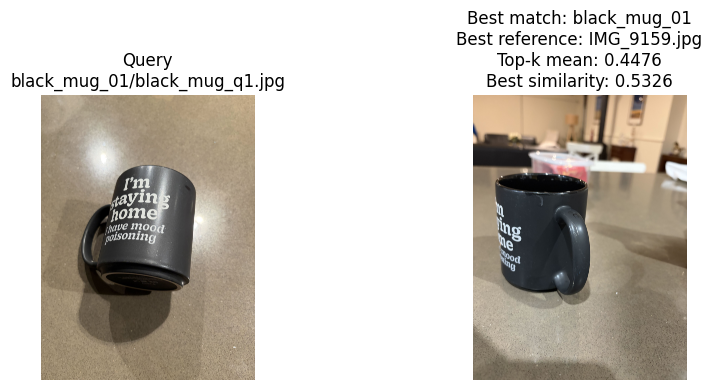

Visual saved: /content/drive/MyDrive/Project_AUTO_ReID/results/match_visuals/black_mug_01_black_mug_q1_match.png


,candidate_identity,reference_image,top_k_mean,best_similarity
0,black_mug_01,IMG_9159.jpg,0.4476,0.5326
1,white_mug_01,IMG_9182.jpg,0.4198,0.4421
2,white_headphone_01,IMG_9170.jpg,0.1018,0.1078
3,book_01,IMG_9179.jpg,0.0652,0.1071


Selected mask: 2
Mask score: 0.9596
Image retained: 42.78%
black_mug_01 all similarities: [0.13078606128692627, 0.21689732372760773, 0.207422137260437, -0.01778816618025303] top-k mean: 0.18503516912460327
book_01 all similarities: [0.02327885292470455, -0.00021746288985013962, 0.029948575422167778, 0.06175217404961586] top-k mean: 0.03832653537392616
white_headphone_01 all similarities: [0.07002333551645279, 0.0486983098089695, 0.034160226583480835, 0.037599798291921616] top-k mean: 0.052107151597738266
white_mug_01 all similarities: [0.14972667396068573, 0.13099847733974457, 0.17735014855861664, 0.17046160995960236] top-k mean: 0.16584615409374237


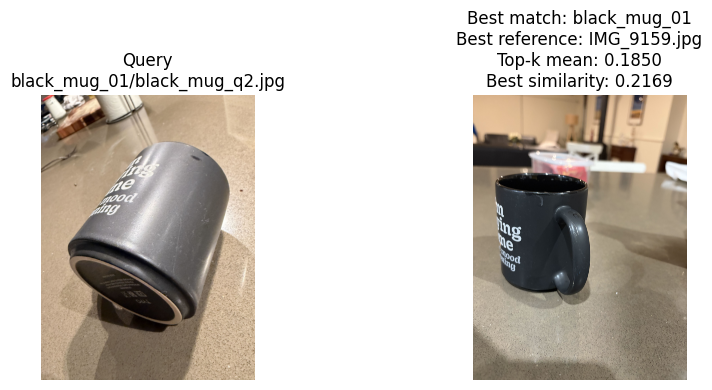

Visual saved: /content/drive/MyDrive/Project_AUTO_ReID/results/match_visuals/black_mug_01_black_mug_q2_match.png


,candidate_identity,reference_image,top_k_mean,best_similarity
0,black_mug_01,IMG_9159.jpg,0.1850,0.2169
1,white_mug_01,IMG_9184.jpg,0.1658,0.1774
2,white_headphone_01,IMG_9170.jpg,0.0521,0.0700
3,book_01,IMG_9179.jpg,0.0383,0.0618


Selected mask: 2
Mask score: 0.9682
Image retained: 39.67%
black_mug_01 all similarities: [0.12499604374170303, 0.08946214616298676, 0.0933162197470665, 0.10054847598075867] top-k mean: 0.1062869131565094
book_01 all similarities: [0.28048229217529297, 0.25255775451660156, 0.46690064668655396, 0.5141787528991699] top-k mean: 0.420520544052124
white_headphone_01 all similarities: [0.019473277032375336, 0.015260129235684872, 0.153743177652359, 0.1411745548248291] top-k mean: 0.10479700565338135
white_mug_01 all similarities: [0.1326037347316742, 0.06512413173913956, 0.07494204491376877, 0.18358945846557617] top-k mean: 0.13037841022014618


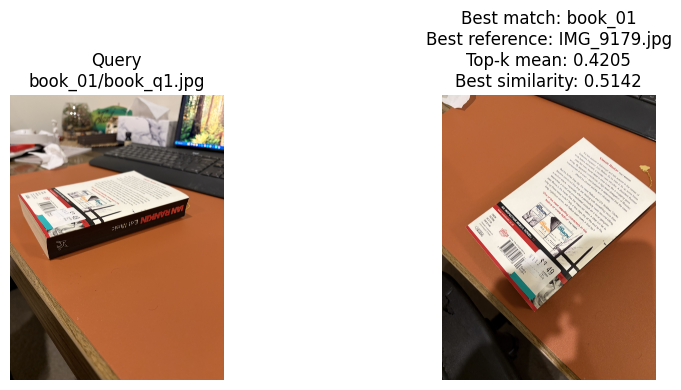

Visual saved: /content/drive/MyDrive/Project_AUTO_ReID/results/match_visuals/book_01_book_q1_match.png


,candidate_identity,reference_image,top_k_mean,best_similarity
0,book_01,IMG_9179.jpg,0.4205,0.5142
1,white_mug_01,IMG_9185.jpg,0.1304,0.1836
2,black_mug_01,IMG_9158.jpg,0.1063,0.1250
3,white_headphone_01,IMG_9172.jpg,0.1048,0.1537


Selected mask: 2
Mask score: 0.9733
Image retained: 47.54%
black_mug_01 all similarities: [0.1518644094467163, 0.05784329026937485, 0.07674330472946167, 0.11692170798778534] top-k mean: 0.1151764765381813
book_01 all similarities: [0.25622105598449707, 0.3113176226615906, 0.32416266202926636, 0.767212986946106] top-k mean: 0.4675644338130951
white_headphone_01 all similarities: [0.05589328706264496, 0.06037219986319542, 0.09584630280733109, 0.2569591701030731] top-k mean: 0.13772588968276978
white_mug_01 all similarities: [0.17917568981647491, 0.09816307574510574, 0.06584502011537552, 0.2838200330734253] top-k mean: 0.187052920460701


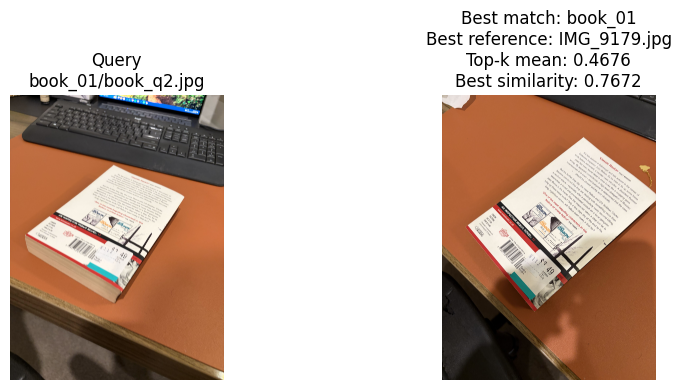

Visual saved: /content/drive/MyDrive/Project_AUTO_ReID/results/match_visuals/book_01_book_q2_match.png


,candidate_identity,reference_image,top_k_mean,best_similarity
0,book_01,IMG_9179.jpg,0.4676,0.7672
1,white_mug_01,IMG_9185.jpg,0.1871,0.2838
2,white_headphone_01,IMG_9173.jpg,0.1377,0.2570
3,black_mug_01,IMG_9158.jpg,0.1152,0.1519


Selected mask: 2
Mask score: 0.9935
Image retained: 50.08%
black_mug_01 all similarities: [0.07020813971757889, 0.05644196644425392, 0.09091842174530029, 0.0715445801615715] top-k mean: 0.0775570496916771
book_01 all similarities: [0.037467002868652344, 0.18077804148197174, 0.24337118864059448, 0.25623661279678345] top-k mean: 0.2267952710390091
white_headphone_01 all similarities: [0.04239733889698982, 0.06473273783922195, 0.06479141116142273, 0.050989363342523575] top-k mean: 0.06017116829752922
white_mug_01 all similarities: [0.09505488723516464, 0.09550806134939194, 0.0634949579834938, 0.08412343263626099] top-k mean: 0.09156212955713272


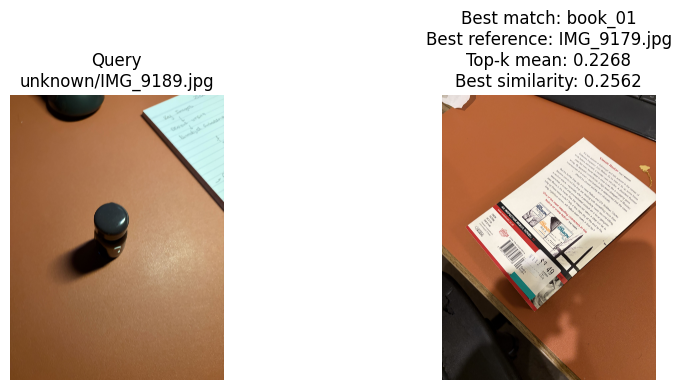

Visual saved: /content/drive/MyDrive/Project_AUTO_ReID/results/match_visuals/unknown_IMG_9189_match.png


,candidate_identity,reference_image,top_k_mean,best_similarity
0,book_01,IMG_9179.jpg,0.2268,0.2562
1,white_mug_01,IMG_9183.jpg,0.0916,0.0955
2,black_mug_01,IMG_9160.jpg,0.0776,0.0909
3,white_headphone_01,IMG_9172.jpg,0.0602,0.0648


Selected mask: 2
Mask score: 0.7428
Image retained: 32.93%
black_mug_01 all similarities: [0.15455617010593414, 0.12417153269052505, 0.11463981121778488, 0.24355381727218628] top-k mean: 0.1740938425064087
book_01 all similarities: [0.0399068184196949, 0.5184468626976013, 0.38299715518951416, 0.09528423845767975] top-k mean: 0.3322427570819855
white_headphone_01 all similarities: [0.07706789672374725, 0.13657689094543457, 0.21885499358177185, 0.21384748816490173] top-k mean: 0.18975979089736938
white_mug_01 all similarities: [0.1734628826379776, 0.1476747840642929, 0.07168400287628174, 0.19633574783802032] top-k mean: 0.1724911332130432


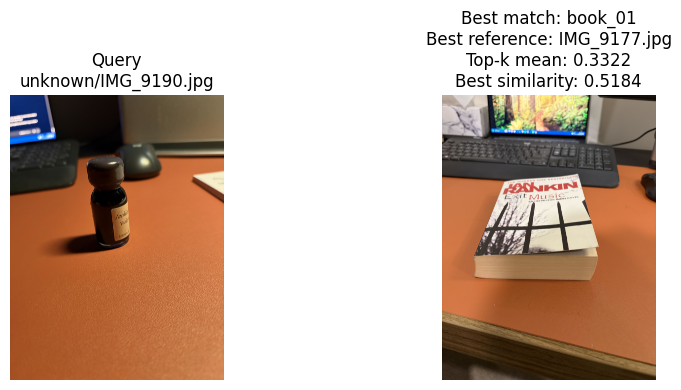

Visual saved: /content/drive/MyDrive/Project_AUTO_ReID/results/match_visuals/unknown_IMG_9190_match.png


,candidate_identity,reference_image,top_k_mean,best_similarity
0,book_01,IMG_9177.jpg,0.3322,0.5184
1,white_headphone_01,IMG_9172.jpg,0.1898,0.2189
2,black_mug_01,IMG_9161.jpg,0.1741,0.2436
3,white_mug_01,IMG_9185.jpg,0.1725,0.1963


Selected mask: 2
Mask score: 0.4146
Image retained: 21.22%
black_mug_01 all similarities: [0.1326400637626648, 0.02510429546236992, -0.010875942185521126, 0.21276715397834778] top-k mean: 0.12350383400917053
book_01 all similarities: [0.04719192907214165, 0.18235619366168976, 0.23501281440258026, 0.06123488396406174] top-k mean: 0.15953463315963745
white_headphone_01 all similarities: [0.06448668241500854, 0.04494593292474747, 0.24785414338111877, 0.2486553192138672] top-k mean: 0.18699872493743896
white_mug_01 all similarities: [0.11869963258504868, 0.12940219044685364, 0.050694774836301804, 0.16932328045368195] top-k mean: 0.13914170861244202


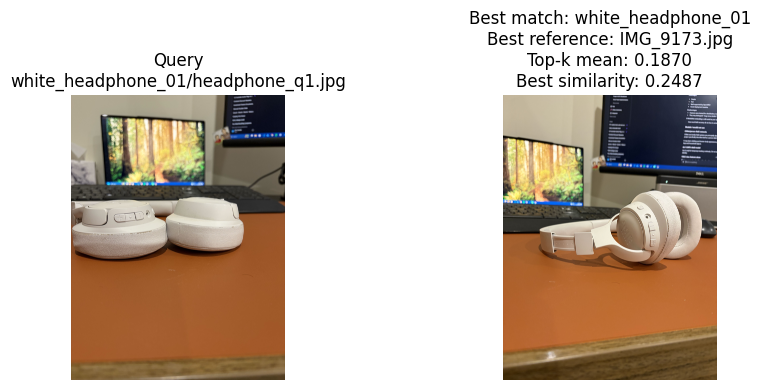

Visual saved: /content/drive/MyDrive/Project_AUTO_ReID/results/match_visuals/white_headphone_01_headphone_q1_match.png


,candidate_identity,reference_image,top_k_mean,best_similarity
0,white_headphone_01,IMG_9173.jpg,0.1870,0.2487
1,book_01,IMG_9178.jpg,0.1595,0.2350
2,white_mug_01,IMG_9185.jpg,0.1391,0.1693
3,black_mug_01,IMG_9161.jpg,0.1235,0.2128


Selected mask: 1
Mask score: 0.7435
Image retained: 19.30%
black_mug_01 all similarities: [0.1272430121898651, 0.022395212203264236, 0.004572137258946896, 0.0594797246158123] top-k mean: 0.06970598548650742
book_01 all similarities: [-0.03124171867966652, 0.038367144763469696, 0.03675372526049614, 0.0717129185795784] top-k mean: 0.04894459620118141
white_headphone_01 all similarities: [0.4085314869880676, 0.3037104904651642, 0.2148333191871643, 0.13689707219600677] top-k mean: 0.3090251088142395
white_mug_01 all similarities: [0.18448896706104279, 0.09301313012838364, 0.09567542374134064, 0.19170229136943817] top-k mean: 0.15728889405727386


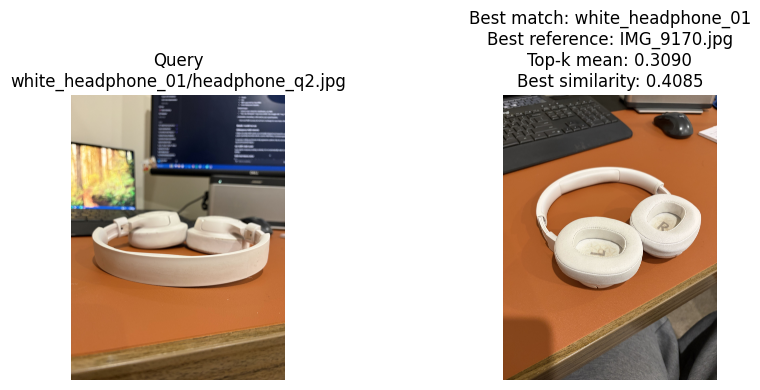

Visual saved: /content/drive/MyDrive/Project_AUTO_ReID/results/match_visuals/white_headphone_01_headphone_q2_match.png


,candidate_identity,reference_image,top_k_mean,best_similarity
0,white_headphone_01,IMG_9170.jpg,0.3090,0.4085
1,white_mug_01,IMG_9185.jpg,0.1573,0.1917
2,black_mug_01,IMG_9158.jpg,0.0697,0.1272
3,book_01,IMG_9179.jpg,0.0489,0.0717


Selected mask: 2
Mask score: 0.9884
Image retained: 77.21%
black_mug_01 all similarities: [0.5844501256942749, 0.6889631748199463, 0.587832510471344, 0.08679094910621643] top-k mean: 0.6204152703285217
book_01 all similarities: [-0.0030415337532758713, 0.10867577791213989, 0.10551883280277252, 0.07674654573202133] top-k mean: 0.09698038548231125
white_headphone_01 all similarities: [0.10977845638990402, 0.10719063878059387, 0.15693849325180054, 0.13909313082695007] top-k mean: 0.13527002930641174
white_mug_01 all similarities: [0.6298118233680725, 0.6792919635772705, 0.4379115700721741, 0.6076654195785522] top-k mean: 0.6389230489730835


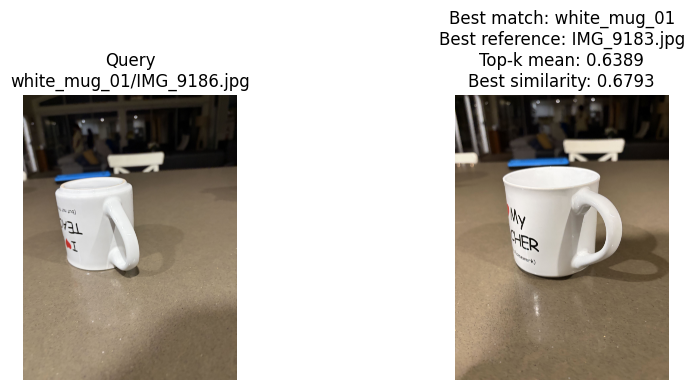

Visual saved: /content/drive/MyDrive/Project_AUTO_ReID/results/match_visuals/white_mug_01_IMG_9186_match.png


,candidate_identity,reference_image,top_k_mean,best_similarity
0,white_mug_01,IMG_9183.jpg,0.6389,0.6793
1,black_mug_01,IMG_9159.jpg,0.6204,0.6890
2,white_headphone_01,IMG_9172.jpg,0.1353,0.1569
3,book_01,IMG_9177.jpg,0.0970,0.1087


Selected mask: 2
Mask score: 0.9340
Image retained: 21.99%
black_mug_01 all similarities: [0.484926700592041, 0.7909553050994873, 0.6404728293418884, 0.055811963975429535] top-k mean: 0.6387849450111389
book_01 all similarities: [0.0072156996466219425, 0.12020508944988251, 0.12060219049453735, 0.027720164507627487] top-k mean: 0.08950915187597275
white_headphone_01 all similarities: [0.08300212770700455, 0.061636172235012054, 0.12446103245019913, 0.09682914614677429] top-k mean: 0.10143076628446579
white_mug_01 all similarities: [0.7310112118721008, 0.8669883012771606, 0.5454832315444946, 0.606700599193573] top-k mean: 0.7349000573158264


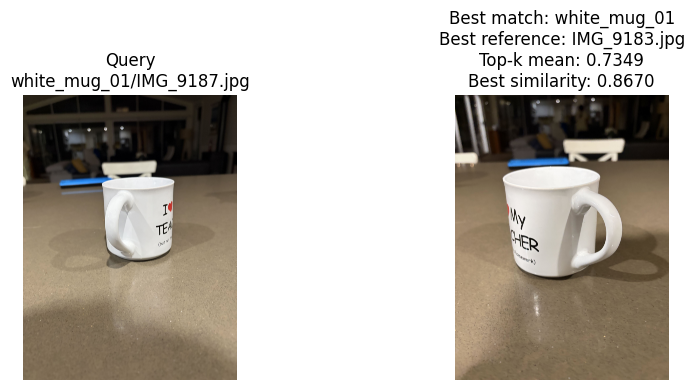

Visual saved: /content/drive/MyDrive/Project_AUTO_ReID/results/match_visuals/white_mug_01_IMG_9187_match.png


,candidate_identity,reference_image,top_k_mean,best_similarity
0,white_mug_01,IMG_9183.jpg,0.7349,0.8670
1,black_mug_01,IMG_9159.jpg,0.6388,0.7910
2,white_headphone_01,IMG_9172.jpg,0.1014,0.1245
3,book_01,IMG_9178.jpg,0.0895,0.1206


,query_identity,query_image,predicted_identity,matched_reference,best_similarity,top_k_mean,second_identity,second_similarity,second_top_k_mean,margin,correct
0,black_mug_01,black_mug_q1.jpg,black_mug_01,IMG_9159.jpg,0.5326,0.4476,white_mug_01,0.4421,0.4198,0.0279,True
1,black_mug_01,black_mug_q2.jpg,black_mug_01,IMG_9159.jpg,0.2169,0.1850,white_mug_01,0.1774,0.1658,0.0192,True
2,book_01,book_q1.jpg,book_01,IMG_9179.jpg,0.5142,0.4205,white_mug_01,0.1836,0.1304,0.2901,True
3,book_01,book_q2.jpg,book_01,IMG_9179.jpg,0.7672,0.4676,white_mug_01,0.2838,0.1871,0.2805,True
4,unknown,IMG_9189.jpg,book_01,IMG_9179.jpg,0.2562,0.2268,white_mug_01,0.0955,0.0916,0.1352,None
5,unknown,IMG_9190.jpg,book_01,IMG_9177.jpg,0.5184,0.3322,white_headphone_01,0.2189,0.1898,0.1425,None
6,white_headphone_01,headphone_q1.jpg,white_headphone_01,IMG_9173.jpg,0.2487,0.1870,book_01,0.2350,0.1595,0.0275,True
7,white_headphone_01,headphone_q2.jpg,white_headphone_01,IMG_9170.jpg,0.4085,0.3090,white_mug_01,0.1917,0.1573,0.1517,True
8,white_mug_01,IMG_9186.jpg,white_mug_01,IMG_9183.jpg,0.6793,0.6389,black_mug_01,0.6890,0.6204,0.0185,True
9,white_mug_01,IMG_9187.jpg,white_mug_01,IMG_9183.jpg,0.8670,0.7349,black_mug_01,0.7910,0.6388,0.0961,True


In [ ]:
all_pairwise_results = []
query_summary_rows = []

for query_path in get_image_paths(QUERY_DIR):
    comparisons, identity_matches = show_query_match(query_path)
    all_pairwise_results.append(comparisons)

    if len(identity_matches) < 2:
        raise RuntimeError(
            "At least two reference identities are required "
            "to calculate the similarity margin."
        )

    best = identity_matches.iloc[0]
    second = identity_matches.iloc[1]
    expected_identity = query_path.parent.name

    query_summary_rows.append({
        "query_identity": expected_identity,
        "query_image": query_path.name,
        "predicted_identity": best["candidate_identity"],
        "matched_reference": best["reference_image"],
        "best_similarity": best["best_similarity"],
        "top_k_mean": best["top_k_mean"],
        "second_identity": second["candidate_identity"],
        "second_similarity": second["best_similarity"],
        "second_top_k_mean": second["top_k_mean"],
        "margin": best["top_k_mean"] - second["top_k_mean"],
        "correct": (
            None
            if expected_identity == "unknown"
            else best["candidate_identity"] == expected_identity
        ),
    })

if not all_pairwise_results:
    raise RuntimeError("No query images were found in QUERY_DIR.")

pairwise_results = pd.concat(all_pairwise_results, ignore_index=True)
query_summary = pd.DataFrame(query_summary_rows)

display(
    query_summary.style.format({
        "best_similarity": "{:.4f}",
        "top_k_mean": "{:.4f}",
        "second_similarity": "{:.4f}",
        "second_top_k_mean": "{:.4f}",
        "margin": "{:.4f}",
    })
)

In [ ]:
pairwise_results.to_csv(
    RESULTS_DIR / "all_pairwise_similarities.csv",
    index=False,
)

query_summary.to_csv(
    RESULTS_DIR / "query_match_summary.csv",
    index=False,
)

print("Results saved successfully.")